In [2]:
import pandas as pd
import os

# This looks for the file in the most likely locations
paths_to_try = [
    '../data/heart_disease.csv',  # If running from 'src'
    'data/heart_disease.csv',     # If running from project root
    'heart_disease.csv'           # If running from inside 'data'
]

df = None
for path in paths_to_try:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ Success! Loaded from: {path}")
        break

if df is not None:
    print(f"Dataset Shape: {df.shape}")
    display(df.head())
else:
    print("Still can't find it. Current Directory is:", os.getcwd())
    print("Files visible here:", os.listdir('.'))

✅ Success! Loaded from: ../data/heart_disease.csv
Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


target
1    526
0    499
Name: count, dtype: int64


/var/folders/qr/xmzqbfk15yzglrc24q0s0vg00000gn/T/ipykernel_90130/102696028.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


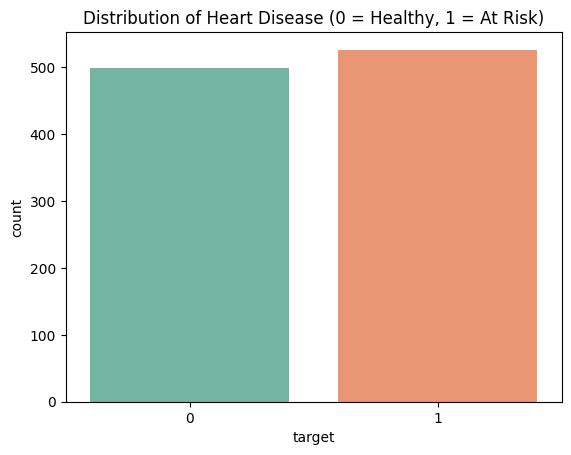

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count the occurrences of each target value
print(df['target'].value_counts())

# Visualize the balance
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution of Heart Disease (0 = Healthy, 1 = At Risk)')
plt.show()

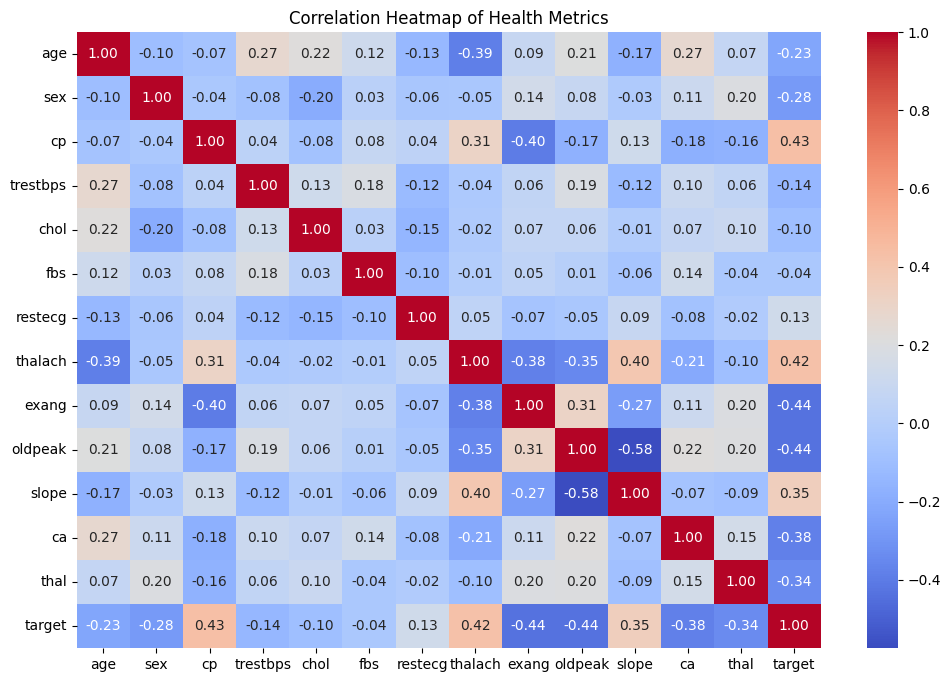

In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Health Metrics')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split into Training (80%) and Testing (20%) sets
# This addresses Risk R2 (Overfitting) by keeping some data hidden from the AI
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (Standardizing makes it easier for the model to learn)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully!")

✅ Data split and scaled successfully!


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Model
model.fit(X_train_scaled, y_train)

# Make Predictions on the test data
y_pred = model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 98.54%


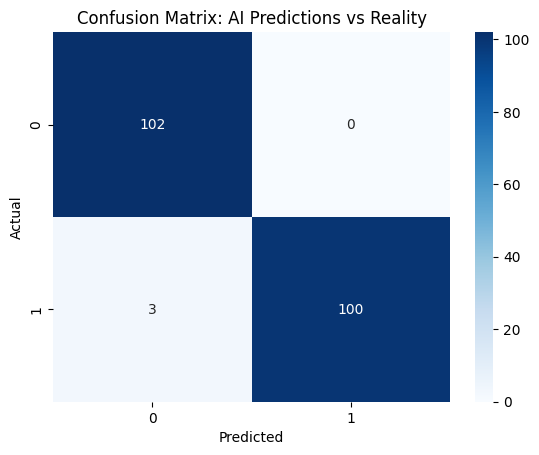


Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [7]:
# Create a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: AI Predictions vs Reality')
plt.show()

# Show the classification report
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

In [8]:
import joblib

# Create the models directory if it doesn't exist (just in case)
os.makedirs('../models', exist_ok=True)

# Save the trained model
joblib.dump(model, '../models/cvd_model.pkl')

# Save the scaler (Crucial: you must scale new user data exactly like the training data)
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and Scaler saved successfully in the 'models/' folder!")

Model and Scaler saved successfully in the 'models/' folder!


In [9]:
# 1. Load the saved model and scaler
loaded_model = joblib.load('../models/cvd_model.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')

# 2. Create a "Fake" User (Age: 55, Sex: 1, Chest Pain: 2, etc.)
# Note: Ensure the values follow the same order as your dataset columns
dummy_user_data = [[55, 1, 1, 130, 250, 0, 1, 145, 0, 1.2, 1, 0, 2]] 

# 3. Scale and Predict
dummy_scaled = loaded_scaler.transform(dummy_user_data)
prediction = loaded_model.predict(dummy_scaled)
probability = loaded_model.predict_proba(dummy_scaled)

if prediction[0] == 1:
    print(f"Result: High Risk of CVD (Confidence: {probability[0][1]*100:.2f}%)")
else:
    print(f"Result: Low Risk of CVD (Confidence: {probability[0][0]*100:.2f}%)")

Result: High Risk of CVD (Confidence: 74.00%)


/Users/sadikshyaduwadi/Desktop/cvd_project/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation to ensure the 1.00 AUC isn't just a lucky split
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print(f"Mean Cross-Validation Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")

Mean Cross-Validation Accuracy: 98.17%
Standard Deviation: 1.59%
